In [1]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive/')
df = pd.read_csv("/content/drive/My Drive/COS351/data.csv")

Mounted at /content/drive/


In [2]:
df = df.drop('Num_Customers_Weekly_M', axis=1)
df

,Company,Sector,Disclosure,Personalized_Pricing,Violation_Risk,Public,Revenue_B,Loyalty_Program,Num_Customers_Monthly_M
0,DoorDash,Food delivery,Yes,Yes,0,Public,13.72,Yes,42.000
1,Grubhub,Food delivery,Yes,Yes,0,Public,2.13,Yes,24.600
2,Ubereats,Food delivery,Yes,Yes,0,Public,13.70,Yes,95.000
3,Instacart,Food delivery,Yes,Yes,0,Public,3.70,Yes,14.400
4,Amazon Fresh,Grocery delivery,No,Yes,4,Public,125.00,Yes,12.500
5,GoPuff,Grocery delivery,No,No,3,Private,1.20,Yes,1.800
6,Misfits Market,Grocery delivery,No,No,2,Private,0.50,Yes,0.500
7,Hungryroot,Meal box delivery,No,No,3,Private,0.70,No,1.500
8,Target,Grocery delivery,Yes,Yes,0,Public,106.00,Yes,120.000
9,FreshDirect,Grocery delivery,No,Yes,4,Private,0.77,Yes,0.250


In [3]:
# converting to binary data
def encode_and_bind(original_dataframe, feature_to_encode):
    dummies = pd.get_dummies(original_dataframe[[feature_to_encode]])
    res = pd.concat([original_dataframe, dummies], axis=1)
    res = res.drop([feature_to_encode], axis=1)
    return(res)

one_hot_labels = ["Sector", "Disclosure", "Personalized_Pricing",
                  "Public", "Loyalty_Program"]
for label in one_hot_labels:
  df = encode_and_bind(df, label)

In [4]:
df = df.drop(['Disclosure_No', 'Loyalty_Program_No',
              'Public_Private', 'Personalized_Pricing_No'], axis=1)
df.rename(columns={'Disclosure_Yes': 'Disclosure',
                   'Personalized_Pricing_Yes': 'Personalized_Pricing',
                   'Public_Public': 'Public',
                   'Loyalty_Program_Yes': 'Loyalty_Program'})

,Company,Violation_Risk,Revenue_B,Num_Customers_Monthly_M,Sector_Food delivery,Sector_Grocery delivery,Sector_Meal box delivery,Sector_Pharmacy,Disclosure,Personalized_Pricing,Public,Loyalty_Program
0,DoorDash,0,13.72,42.000,True,False,False,False,True,True,True,True
1,Grubhub,0,2.13,24.600,True,False,False,False,True,True,True,True
2,Ubereats,0,13.70,95.000,True,False,False,False,True,True,True,True
3,Instacart,0,3.70,14.400,True,False,False,False,True,True,True,True
4,Amazon Fresh,4,125.00,12.500,False,True,False,False,False,True,True,True
5,GoPuff,3,1.20,1.800,False,True,False,False,False,False,False,True
6,Misfits Market,2,0.50,0.500,False,True,False,False,False,False,False,True
7,Hungryroot,3,0.70,1.500,False,False,True,False,False,False,False,False
8,Target,0,106.00,120.000,False,True,False,False,True,True,True,True
9,FreshDirect,4,0.77,0.250,False,True,False,False,False,True,False,True


In [5]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['Revenue_B'] = scaler.fit_transform(df[['Revenue_B']])
df['Num_Customers_Monthly_M'] = scaler.fit_transform(df[['Num_Customers_Monthly_M']])

Text(0, 0.5, 'Company')

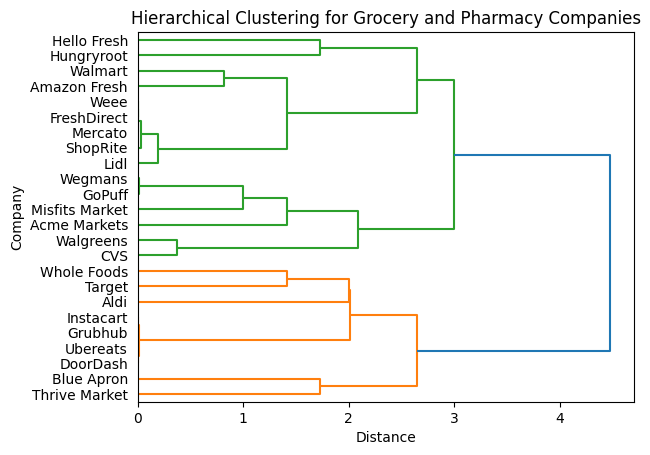

In [6]:
from scipy.cluster import hierarchy
import matplotlib.pyplot as plt
%matplotlib inline

# hierarchical clustering without monthly customers

companies = df['Company']
X = df.drop(['Company', 'Num_Customers_Monthly_M'],axis=1)
X
Z = hierarchy.linkage(X.to_numpy(), 'complete')
dn = hierarchy.dendrogram(Z,labels=companies.tolist(),orientation='right')
plt.title('Hierarchical Clustering for Grocery and Pharmacy Companies')
plt.xlabel('Distance')
plt.ylabel('Company')

Text(0, 0.5, 'Company')

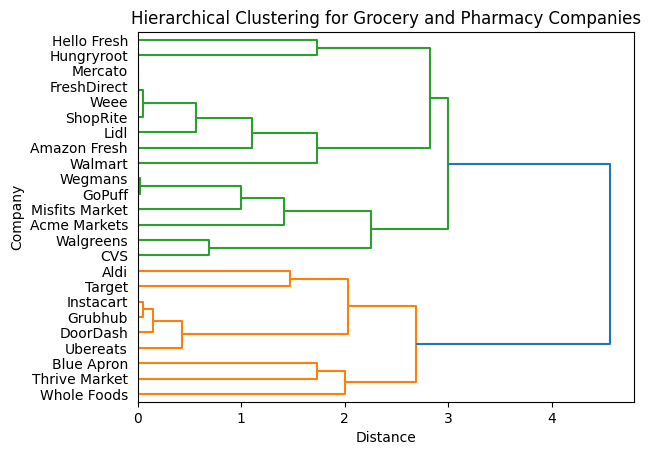

In [7]:
# hierarchical clustering

companies = df['Company']
X = df.drop(['Company'],axis=1)
X
Z = hierarchy.linkage(X.to_numpy(), 'complete')
dn = hierarchy.dendrogram(Z,labels=companies.tolist(),orientation='right')
plt.title('Hierarchical Clustering for Grocery and Pharmacy Companies')
plt.xlabel('Distance')
plt.ylabel('Company')

Text(0, 0.5, 'Company')

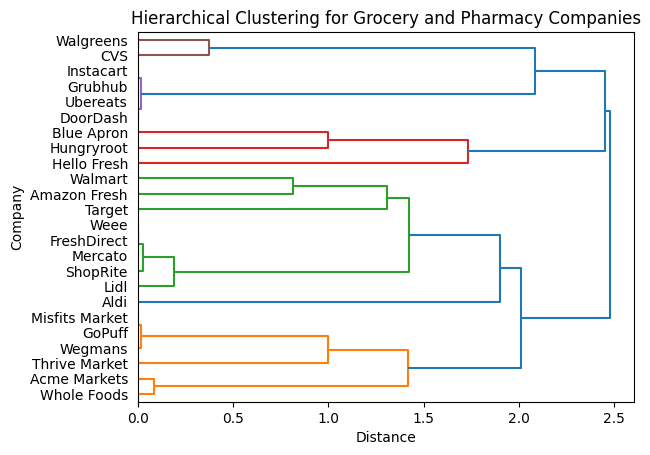

In [8]:
# hierarchical clustering without added features

companies = df['Company']
X = df.drop(['Company', 'Num_Customers_Monthly_M', 'Violation_Risk'],axis=1)
Z = hierarchy.linkage(X.to_numpy(), 'complete')
dn = hierarchy.dendrogram(Z,labels=companies.tolist(),orientation='right')
plt.title('Hierarchical Clustering for Grocery and Pharmacy Companies')
plt.xlabel('Distance')
plt.ylabel('Company')

In [9]:
# k means clustering
from sklearn import cluster

# determine optimal number of clusters for k-means clustering
def get_best_k_clusters(data, max_k=11):
  SSE = []
  for k in range(1,max_k):
      k_means = cluster.KMeans(n_clusters=k)
      k_means.fit(data)
      SSE.append(k_means.inertia_)

  plt.plot(range(1,max_k), SSE)
  plt.xlabel('Number of Clusters (k)')
  plt.ylabel('SSE')
  plt.title('Elbow Method for Optimal k')

In [11]:
!pip install adjustText

In [18]:
from adjustText import adjust_text
from sklearn.decomposition import PCA

def get_cluster_assignments(data, k=2):
  k_means = cluster.KMeans(n_clusters=k, max_iter=50, random_state=1)
  k_means.fit(data)
  labels = k_means.labels_
  pd.DataFrame(labels, index=df.Company, columns=['Cluster ID'])
  return labels

def perform_PCA(data):
  # PCA: reduce high dimensional data to d=2
  pca_2 = PCA(n_components=2)
  pca_2_result = pca_2.fit_transform(data)
  print('Explained variation per principal component: {}'.format(pca_2.explained_variance_ratio_))

  print('Cumulative variance explained by 2 principal components: {:.2%}'.format(np.sum(pca_2.explained_variance_ratio_)))
  return pca_2_result

def visualize_clusters(results, labels, k):
  plt.scatter(results[:, 0], results[:, 1], c=labels)
  texts = []
  for x, y, company in zip(results[:, 0], results[:, 1], df.Company):
      texts.append(plt.text(x, y, company))

  # This one line handles all the magic of preventing overlaps!
  adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))
  plt.title(f'k-Means Clustering for Grocery and Pharmacy Companies (k = {k})')
  plt.xlabel('Principal Component 1')
  plt.ylabel('Principal Component 2')

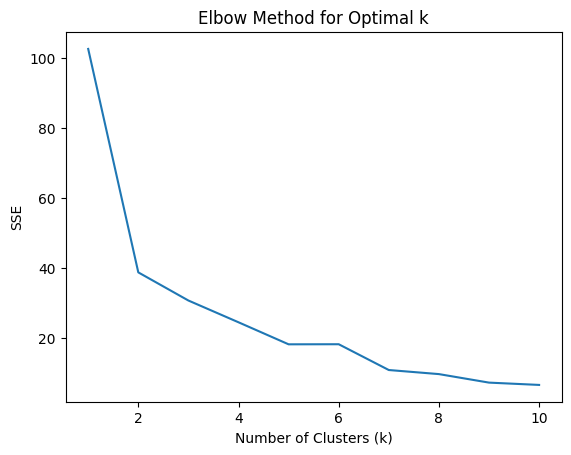

In [16]:
# clusters with all data
cluster_data = df.drop('Company',axis=1)
get_best_k_clusters(cluster_data)


Explained variation per principal component: [0.70203652 0.09438513]
Cumulative variance explained by 2 principal components: 79.64%


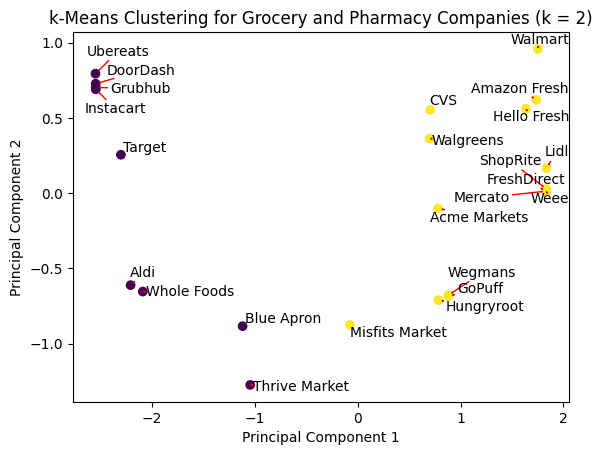

In [20]:
import numpy as np
# clusters with all data
clusters = get_cluster_assignments(cluster_data)
pca_results = perform_PCA(cluster_data)
visualize_clusters(pca_results, clusters, k=2)

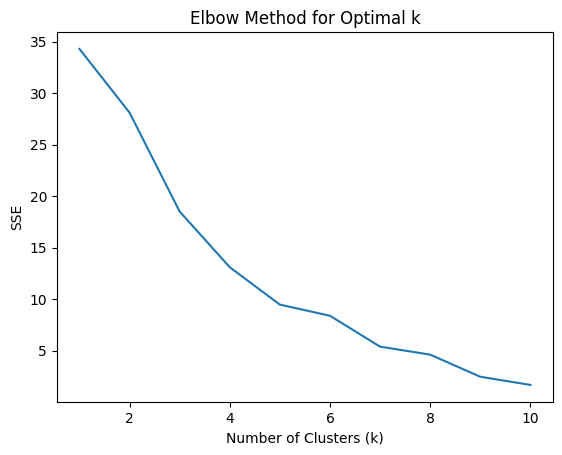

In [26]:
# clusters excluding num customers and violation risk
cluster_data1 = df.drop(['Company', 'Num_Customers_Monthly_M', 'Violation_Risk'],axis=1)
get_best_k_clusters(cluster_data1)

Explained variation per principal component: [0.37108553 0.22600811]
Cumulative variance explained by 2 principal components: 59.71%


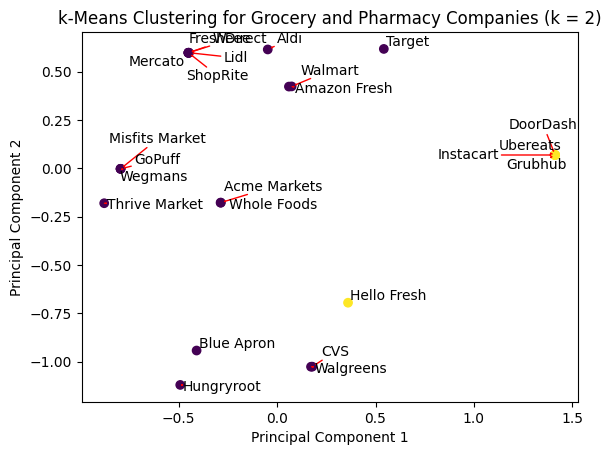

In [27]:
# clusters excluding num customers and violation risk
clusters1 = get_cluster_assignments(cluster_data1)
pca_results1 = perform_PCA(cluster_data1)
visualize_clusters(pca_results1, clusters1, 2)

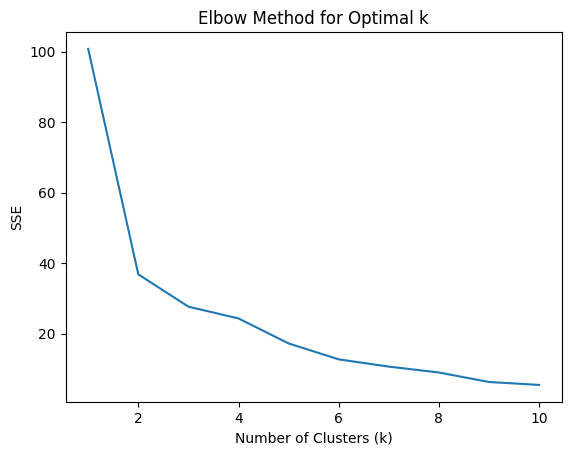

In [86]:
# clusters excluding num customers
cluster_data2 = df.drop(['Company', 'Num_Customers_Monthly_M'],axis=1)
get_best_k_clusters(cluster_data2)

Explained variation per principal component: [0.71546941 0.09178176]
Cumulative variance explained by 2 principal components: 80.73%


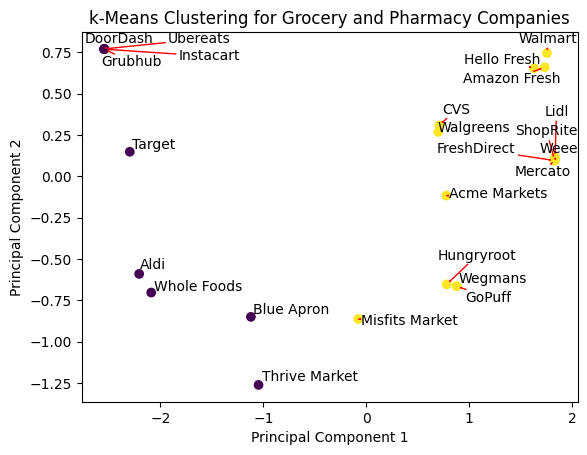

In [71]:
# clusters excluding num customers
clusters2 = get_cluster_assignments(cluster_data2)
pca_results2 = perform_PCA(cluster_data2)
visualize_clusters(pca_results2, clusters2)

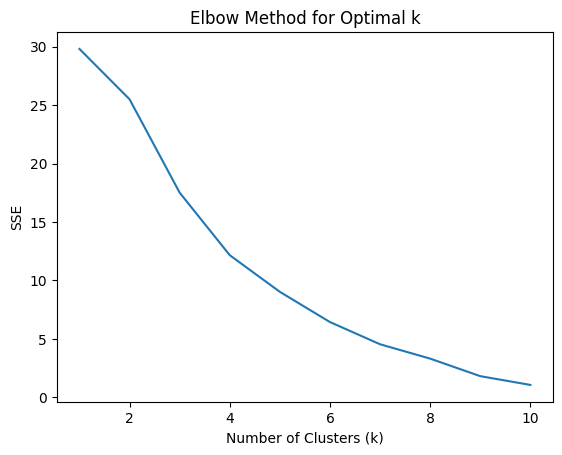

In [28]:
# clusters excluding num customers and violation risk, disclosure: can we cluster companies with the disclosure statement/in compliance together?
cluster_data3 = df.drop(['Company', 'Num_Customers_Monthly_M', 'Violation_Risk', 'Disclosure_Yes'],axis=1)
get_best_k_clusters(cluster_data3)

Explained variation per principal component: [0.34951406 0.24742739]
Cumulative variance explained by 2 principal components: 59.69%


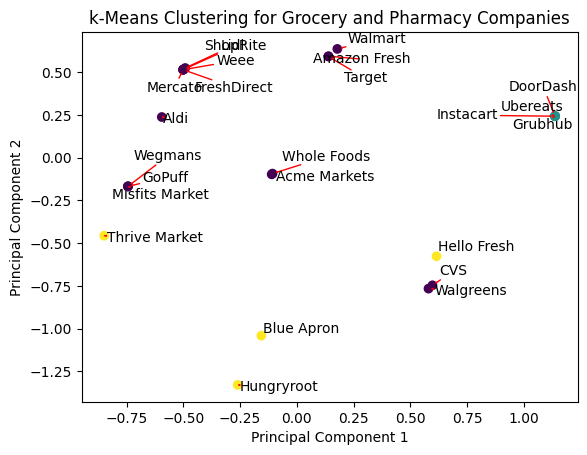

In [77]:
clusters3 = get_cluster_assignments(cluster_data3, k=3)
pca_results3 = perform_PCA(cluster_data3)
visualize_clusters(pca_results3, clusters3)

Explained variation per principal component: [0.34951406 0.24742739]
Cumulative variance explained by 2 principal components: 59.69%


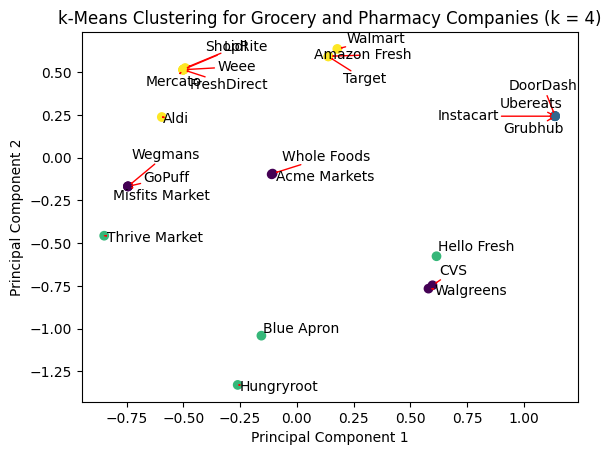

In [30]:
# 4 clusters
clusters3 = get_cluster_assignments(cluster_data3, k=4)
pca_results3 = perform_PCA(cluster_data3)
visualize_clusters(pca_results3, clusters3, 4)

Explained variation per principal component: [0.70203652 0.09438513]
Cumulative variance explained by 2 principal components: 79.64%


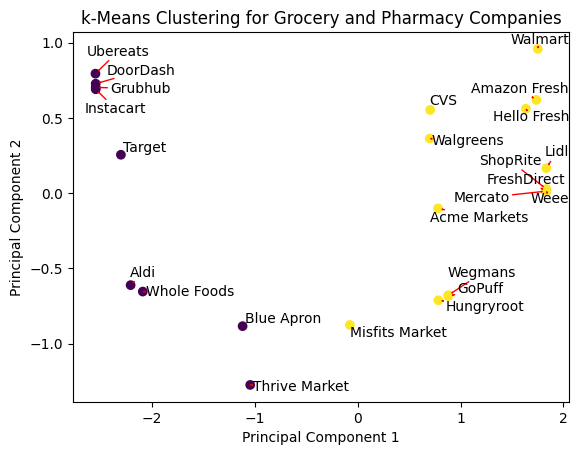

In [88]:
# pca before k means clustering
# clusters with all data
pca_data = perform_PCA(cluster_data)
clusters_after_pca = get_cluster_assignments(pca_data)
visualize_clusters(pca_data, clusters_after_pca)

Explained variation per principal component: [0.37108553 0.22600811]
Cumulative variance explained by 2 principal components: 59.71%


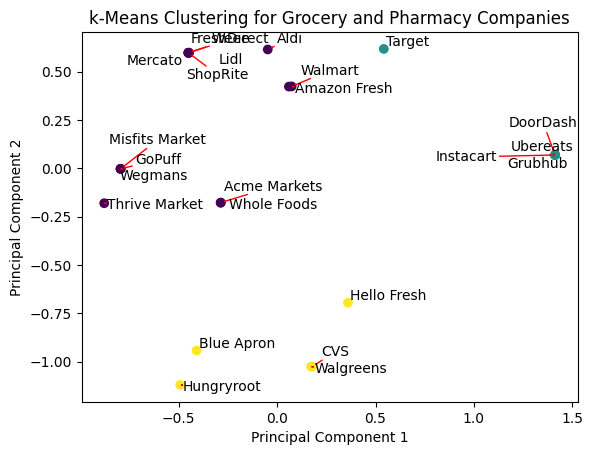

In [91]:
# cluster after pca
# clusters excluding num customers and violation risk
pca_data1 = perform_PCA(cluster_data1)
clusters_after_pca1 = get_cluster_assignments(pca_data1, k=3)
visualize_clusters(pca_data1, clusters_after_pca1)

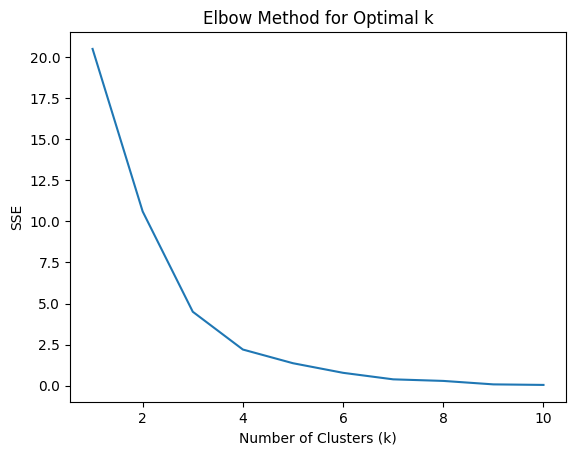

In [90]:
get_best_k_clusters(pca_data1)

Explained variation per principal component: [0.71546941 0.09178176]
Cumulative variance explained by 2 principal components: 80.73%


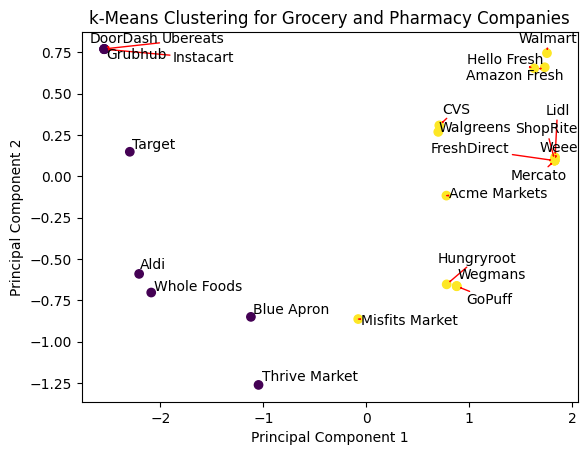

In [92]:
# cluster after pca
# clusters excluding num customers
pca_data2 = perform_PCA(cluster_data2)
clusters_after_pca2 = get_cluster_assignments(pca_data2)

visualize_clusters(pca_data2, clusters_after_pca2)

Explained variation per principal component: [0.34951406 0.24742739]
Cumulative variance explained by 2 principal components: 59.69%


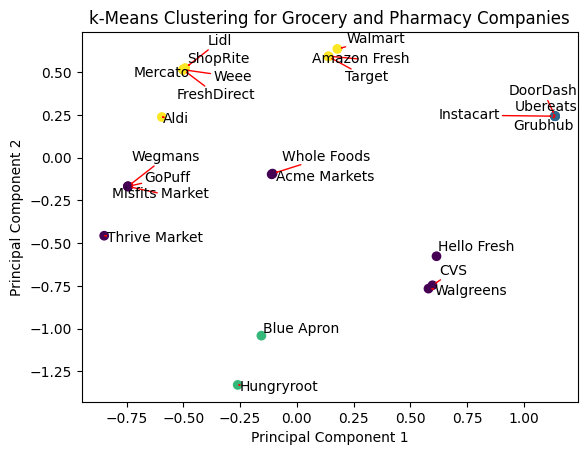

In [96]:
# clusters excluding num customers and violation risk, disclosure: can we cluster companies with the disclosure statement/in compliance together?
pca_data3 = perform_PCA(cluster_data3)
clusters_after_pca3 = get_cluster_assignments(pca_data3, k=4)

visualize_clusters(pca_data3, clusters_after_pca3)

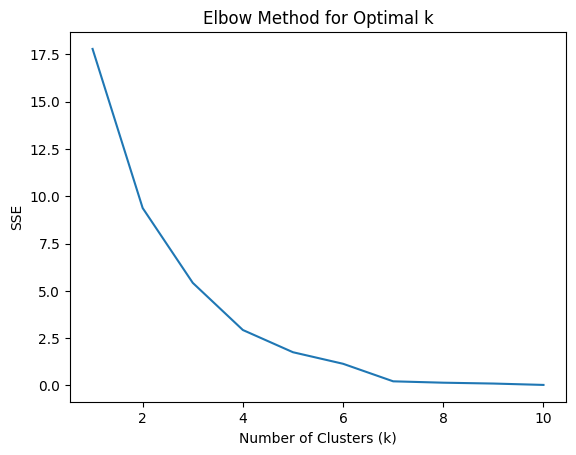

In [95]:
get_best_k_clusters(pca_data3)